In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data .csv')
print(df.shape)

(13580, 21)


In [26]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
 {'Missing Count': missing_counts,
 'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values
print(final_report)

<bound method DataFrame.sort_values of               Missing Count  Percentage (%)
Car                      62        0.456554
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001>


In [27]:
df['Car'] = df['Car'].fillna(0)

# remove duplicated rows
df = df.drop_duplicates()

# Fix the Date data type mismatch so it plots chronologically
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

In [28]:
print("Check")
print("Number of properties with 0 Landsize left:", (df['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df))

Check
Number of properties with 0 Landsize left: 1939
Number of properties with 0 Building area left: 17
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 13580


Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

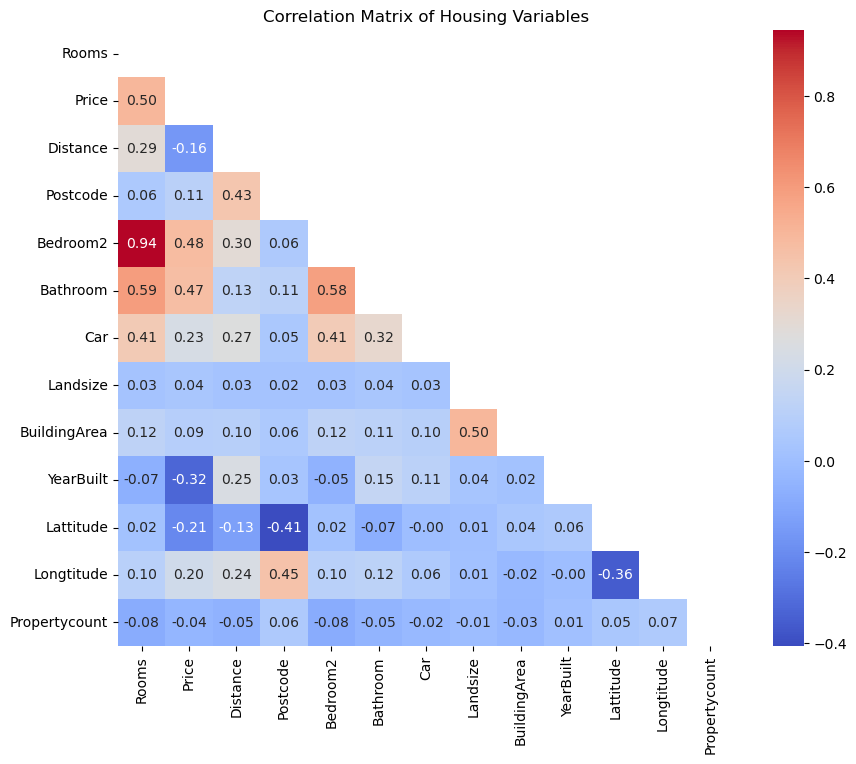

In [29]:
corr = df.corr(numeric_only=True)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True)

plt.title("Correlation Matrix of Housing Variables")

In [30]:
# remove columns that we do not need
df = df.drop(
    columns=[
        "BuildingArea",
        "SellerG",
        "Date",
        "Postcode",
        "Address",
        "Propertycount",
        "Method",
        "YearBuilt",
        "Suburb",
        "CouncilArea"
        "Bedroom2"],
    errors="ignore",
)

# creates new features for analysing
df = df.assign(
    Price_per_Landsize = lambda x: x['Price'] / x['Landsize'],
    Distance_Category = pd.cut(
        df['Distance'],
        bins=[0, 10, 20, 30, float('inf')],
        labels=['Near', 'Middle', 'Far', 'Outer']
    )
)

Text(0.5, 1.0, 'Correlation Matrix of Housing Variables')

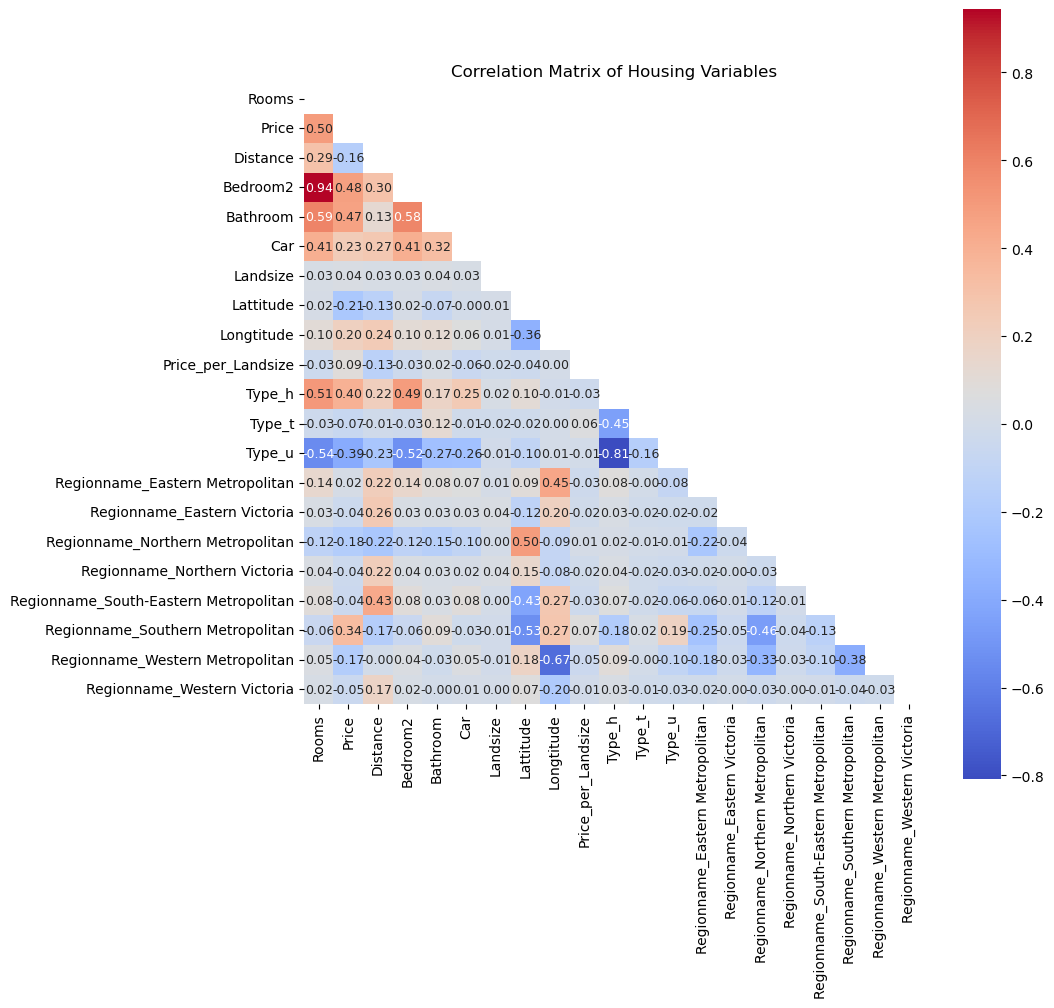

In [31]:
# Convert text columns into numeric binary columns (0 or 1)
df_encoded = pd.get_dummies(df, columns=["Type", "Regionname"])

# Now calculate correlation on the newly encoded dataset
corr = df_encoded.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 10))

# Pass the mask into the heatmap function
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", square=True, annot_kws={"size": 9})

plt.title("Correlation Matrix of Housing Variables")

In [32]:
# Clean Landsize
Q1_land = df["Landsize"].quantile(0.25)
Q3_land = df["Landsize"].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df = df[(df["Landsize"] >= lower_land) & (df["Landsize"] <= upper_land)]

# Clean Price
Q1_price = df["Price"].quantile(0.25)
Q3_price = df["Price"].quantile(0.75)
IQR_price = Q3_price - Q1_price
lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price
df = df[(df["Price"] >= lower_price) & (df["Price"] <= upper_price)]

# Clean Price per landsize
Q1_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.25)
Q3_Price_per_Landsize = df["Price_per_Landsize"].quantile(0.75)
IQR_Price_per_Landsize = Q3_Price_per_Landsize - Q1_Price_per_Landsize
lower_Price_per_Landsize = Q1_Price_per_Landsize - 1.5 * IQR_Price_per_Landsize
upper_Price_per_Landsize = Q3_Price_per_Landsize + 1.5 * IQR_Price_per_Landsize
df = df[(df["Price_per_Landsize"] >= lower_Price_per_Landsize) & (df["Price_per_Landsize"] <= upper_Price_per_Landsize)]


print("Total rows remaining:", len(df))

Total rows remaining: 10579


In [33]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

                   Missing Count  Percentage (%)
CouncilArea                 1243       11.749693
Distance_Category              1        0.009453


In [34]:
# remove the 1 missing value for Distance Category
df = df.dropna(subset=["Distance_Category"])
missing_count = df["Distance_Category"].isna().sum()

print(f"Missing values in Distance_category: {missing_count}")

Missing values in Distance_category: 0


In [35]:
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))

Remaining inf values: 0
Total rows remaining: 10578


In [36]:
# 1. Replace all inf and -inf values with NaN in the Price_per_landsize column
df["Price_per_Landsize"] = df["Price_per_Landsize"].replace(
    [np.inf, -np.inf], np.nan
)

# 2. Drop the rows where Price_per_landsize is now NaN
df = df.dropna(subset=["Price_per_Landsize"])

# Verify that all inf values are gone
print("Remaining inf values:", np.isinf(df["Price_per_Landsize"]).sum())
print("Total rows remaining:", len(df))

Remaining inf values: 0
Total rows remaining: 10578


In [37]:
df.head()

,Rooms,Type,Price,Distance,Bedroom2,Bathroom,Car,Landsize,CouncilArea,Lattitude,Longtitude,Regionname,Price_per_Landsize,Distance_Category
0,2,h,1480000.0,2.5,2.0,1.0,1.0,202.0,Yarra,-37.7996,144.9984,Northern Metropolitan,7326.732673,Near
1,2,h,1035000.0,2.5,2.0,1.0,0.0,156.0,Yarra,-37.8079,144.9934,Northern Metropolitan,6634.615385,Near
2,3,h,1465000.0,2.5,3.0,2.0,0.0,134.0,Yarra,-37.8093,144.9944,Northern Metropolitan,10932.835821,Near
3,3,h,850000.0,2.5,3.0,2.0,1.0,94.0,Yarra,-37.7969,144.9969,Northern Metropolitan,9042.553191,Near
5,2,h,941000.0,2.5,2.0,1.0,0.0,181.0,Yarra,-37.8041,144.9953,Northern Metropolitan,5198.895028,Near


In [38]:
df.to_csv('cleaned_melb_dataset.csv', index = False)

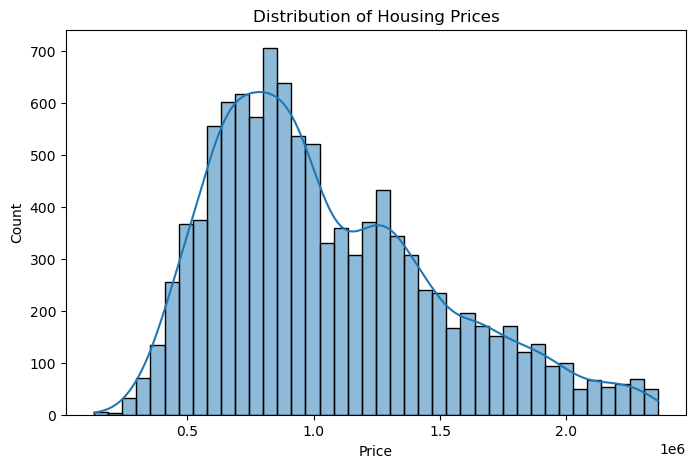

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=40, kde=True)

plt.title("Distribution of Housing Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

Most houses are in the lower-to-middle price range, with a few expensive properties extending the distribution.

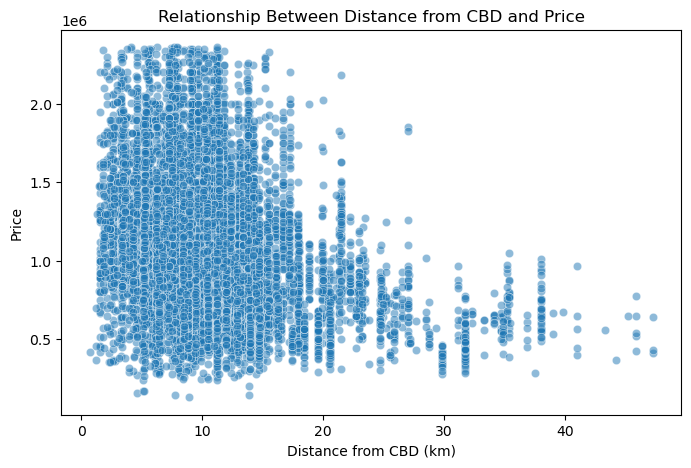

In [40]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Distance", y="Price", alpha=0.5)

plt.title("Relationship Between Distance from CBD and Price")
plt.xlabel("Distance from CBD (km)")
plt.ylabel("Price")

plt.show()

As distance from the CBD increases, prices generally decrease and high-priced properties become less common.

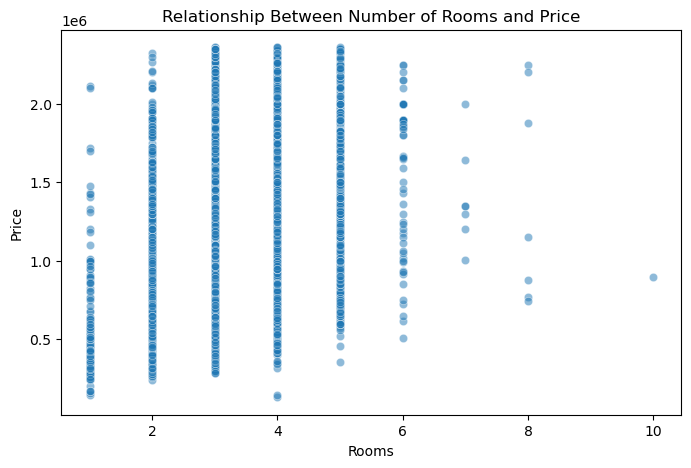

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Rooms", y="Price", alpha=0.5)

plt.title("Relationship Between Number of Rooms and Price")
plt.xlabel("Rooms")
plt.ylabel("Price")

plt.show()

More rooms generally lead to higher prices, although prices still vary within the same room count.

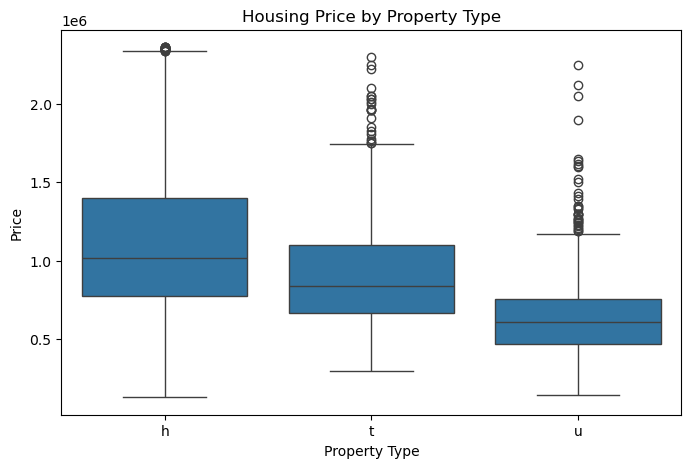

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Type", y="Price")
plt.title("Housing Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price")
plt.show()

Houses have the highest prices, followed by townhouses, while units are the lowest.

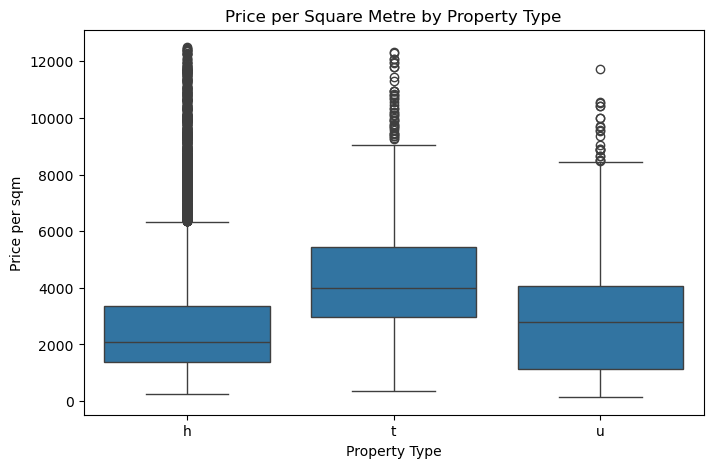

In [43]:

df["Price_per_sqm"] = df["Price"] / df["Landsize"]
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Type", y="Price_per_sqm")
plt.title("Price per Square Metre by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price per sqm")
plt.show()

ownhouses and units have relatively higher price per square metre, showing that total price does not fully represent value.

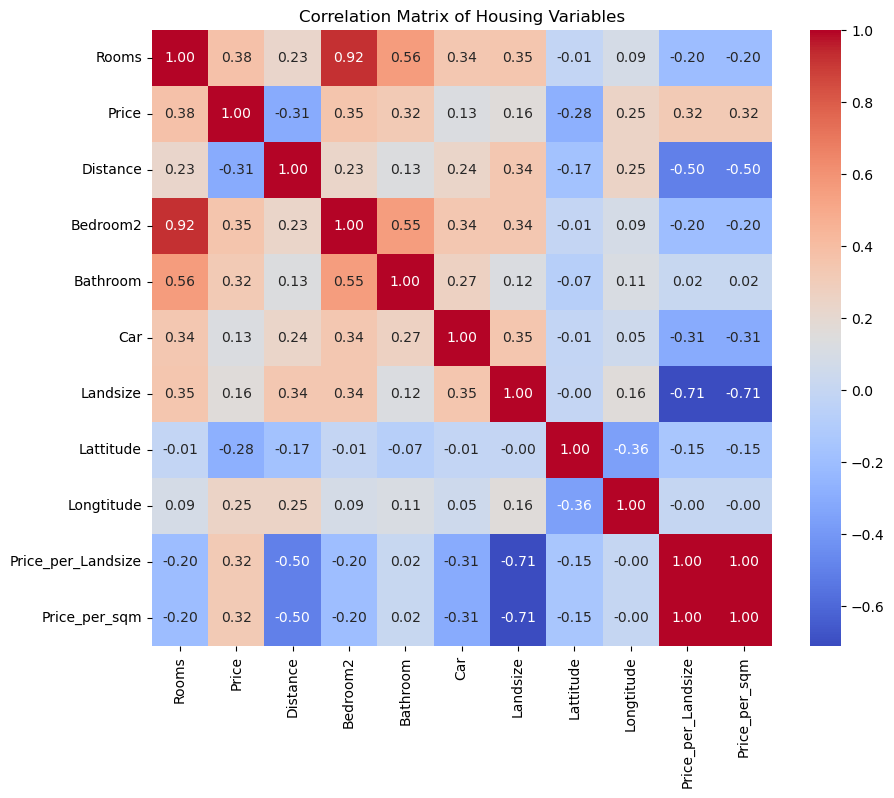

In [44]:

numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10,8))
sns.heatmap(
numeric_df.corr(),
annot=True,
cmap="coolwarm",
fmt=".2f"
)
plt.title("Correlation Matrix of Housing Variables")
plt.show()

After cleaning the data, the relationships between price and key variables become more stable.

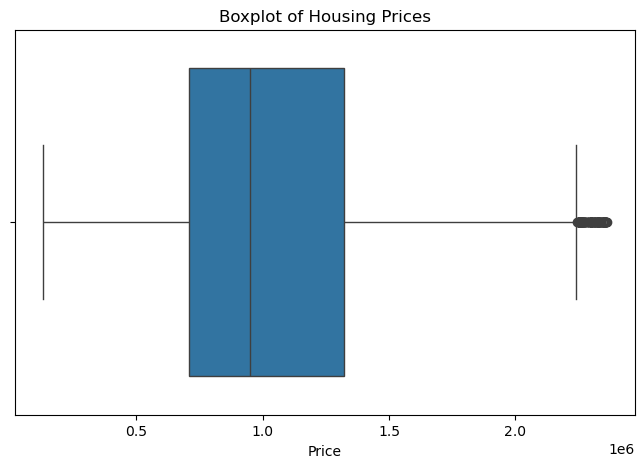

In [45]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Housing Prices")
plt.show()

Most prices are concentrated in the middle range, but some high-price outliers remain.

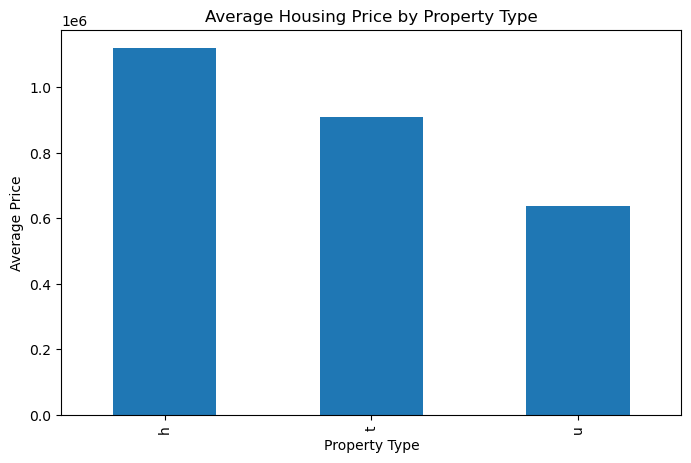

In [46]:

avg_price = df.groupby("Type")["Price"].mean()
plt.figure(figsize=(8,5))
avg_price.plot(kind="bar")
plt.title("Average Housing Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Price")
plt.show()

Average prices show that houses are the most expensive and units are the cheapest.

Linear Regression
R2 Score: 0.34
MAE: 289675.53
RMSE: 371073.06


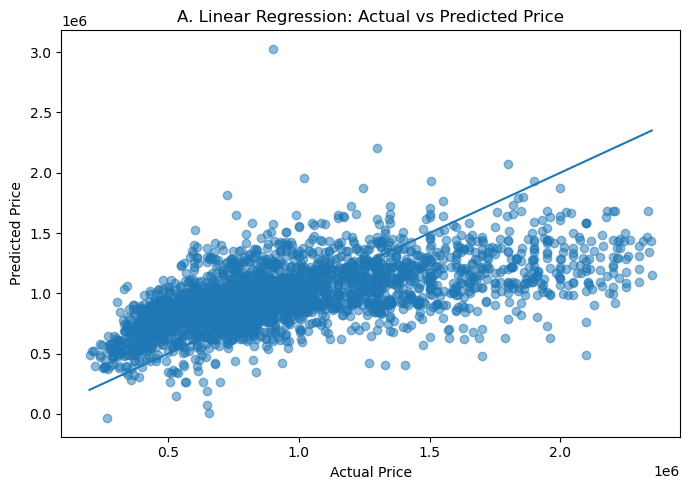


Polynomial Regression
R2 Score: 0.36
MAE: 277832.13
RMSE: 366296.83


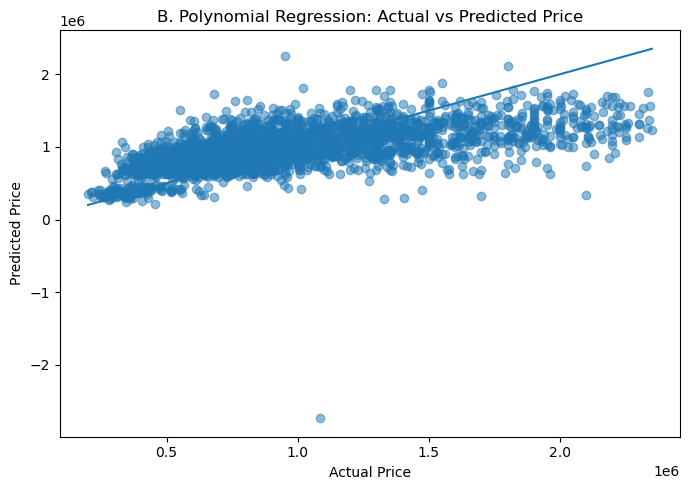


KNN Regression
R2 Score: 0.56
MAE: 219609.69
RMSE: 305484.66


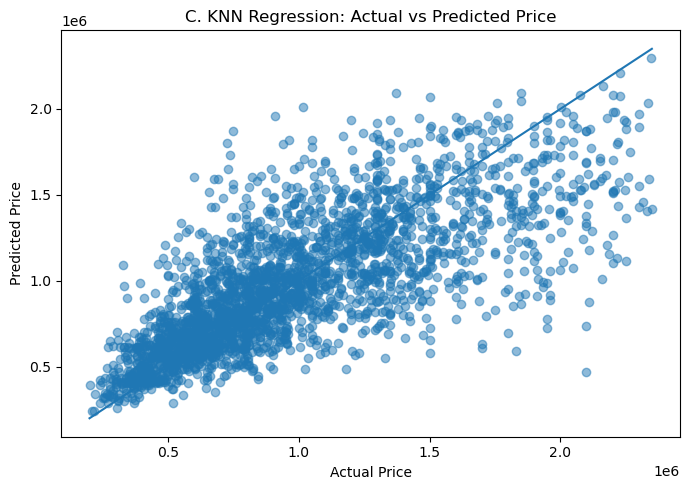

In [47]:
# ==============================
# Modeling: Linear, Polynomial, KNN
# Melbourne Housing Dataset
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Read data
df = pd.read_csv("melb_data .csv")

# 2. Select useful columns
df = df[["Price", "Rooms", "Distance", "Landsize"]].dropna()

# 3. Remove outliers using IQR
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df["Price"] >= Q1 - 1.5 * IQR) &
    (df["Price"] <= Q3 + 1.5 * IQR)
]

# 4. Features and target
X = df[["Rooms", "Distance", "Landsize"]]
y = df["Price"]

# 5. Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# A. Linear Regression
# ==============================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Linear Regression")
print("R2 Score:", round(r2_score(y_test, linear_pred), 2))
print("MAE:", round(mean_absolute_error(y_test, linear_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, linear_pred)), 2))

plt.figure(figsize=(7, 5))
plt.scatter(y_test, linear_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("A. Linear Regression: Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.tight_layout()
plt.show()


# ==============================
# B. Polynomial Regression
# ==============================

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

poly_pred = poly_model.predict(X_test_poly)

print("\nPolynomial Regression")
print("R2 Score:", round(r2_score(y_test, poly_pred), 2))
print("MAE:", round(mean_absolute_error(y_test, poly_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, poly_pred)), 2))

plt.figure(figsize=(7, 5))
plt.scatter(y_test, poly_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("B. Polynomial Regression: Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.tight_layout()
plt.show()


# ==============================
# C. KNN Regression
# ==============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("\nKNN Regression")
print("R2 Score:", round(r2_score(y_test, knn_pred), 2))
print("MAE:", round(mean_absolute_error(y_test, knn_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, knn_pred)), 2))

plt.figure(figsize=(7, 5))
plt.scatter(y_test, knn_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("C. KNN Regression: Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.tight_layout()
plt.show()